## Data Preprocessing Phase

### Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Importing the dataset

In [2]:
dataset = pd.read_csv('creditcard.csv')
X = dataset.drop('Class', axis=1)
y = dataset['Class']

In [3]:

print("First 5 rows of the dataset:")
print(dataset.head())

First 5 rows of the dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

### Splitting the dataset into the Training set and Test set

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0, stratify=y)
X_train = X_train.copy()
X_test = X_test.copy()

### Feature Scaling

In [5]:
from sklearn.preprocessing import RobustScaler
rc = RobustScaler()

# Fit and transform on the training set
X_train[['Amount', 'Time']] = rc.fit_transform(X_train[['Amount', 'Time']])

# ONLY transform on the test set
X_test[['Amount', 'Time']] = rc.transform(X_test[['Amount', 'Time']])

print("Scaling successful!")

Scaling successful!


## SMOTE Integration

### Importing SMOTE

In [6]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

### Applying SMOTE to the training data to balance the classes

In [7]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [8]:
print("Before SMOTE (Training Set):")
print(y_train.value_counts())

Before SMOTE (Training Set):
Class
0    213236
1       369
Name: count, dtype: int64


In [9]:
print("After SMOTE (Training Set):")
print(y_train_resampled.value_counts())

After SMOTE (Training Set):
Class
0    213236
1    213236
Name: count, dtype: int64


## Training the Classification Model

### Importing the Classification models


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

### Store all your models in a dictionary

In [11]:
models = {
    "Naive Bayes": GaussianNB(),
    
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=0),
    
    "Random Forest": RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0, n_jobs=-1),
    
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    
    # --- SVM models may take several hours to train on 400k+ rows ---
    # "Linear SVM": SVC(kernel='linear', random_state=0),
    # "Kernel SVM (RBF)": SVC(kernel='rbf', random_state=0)
}

### Looping through each model, training it, and printing the classification report

In [12]:
for name, model in models.items():
    print(f"========== Training {name} ==========")
    
    # Training the model on the perfectly balanced SMOTE data
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predicting on the untouched, imbalanced test data
    y_pred = model.predict(X_test)
    
    # Printing  the F1-Scores, Precision, and Recall
    print(classification_report(y_test, y_pred))
    print("\n")

========== Training Naive Bayes ==========
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     71079
           1       0.05      0.84      0.10       123

    accuracy                           0.97     71202
   macro avg       0.53      0.91      0.54     71202
weighted avg       1.00      0.97      0.99     71202



========== Training Decision Tree ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.40      0.81      0.53       123

    accuracy                           1.00     71202
   macro avg       0.70      0.91      0.77     71202
weighted avg       1.00      1.00      1.00     71202



========== Training Random Forest ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.91      0.81      0.86       123

    accuracy                           1.00  

## Confusion Matrix of the winning model


### Importing the confusion matrix

In [17]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

### Retrieving the winning Random Forest model from your dictionary

In [18]:
winning_model = models["Random Forest"]

### Generating predictions specifically for this model

In [19]:
y_pred_rf = winning_model.predict(X_test)

### Visualize the matrix with a professional heatmap

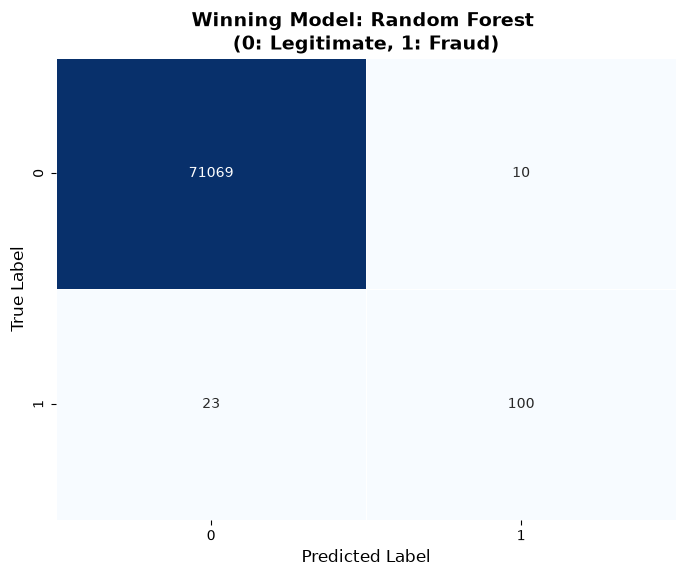

In [20]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False)
plt.title('Winning Model: Random Forest \n(0: Legitimate, 1: Fraud)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()